# EDA para Predicción de Fraude

Este notebook realiza un análisis exploratorio detallado de transacciones con foco en:

- Distribución de clases de `is_fraud`.
- Temporalidad de transacciones y del fraude.
- Medidas de tendencia central y dispersión de `amt`.
- Hallazgos accionables para el modelado predictivo.

Archivo objetivo: **EDA.ipynb**.

## 1. Configuración del notebook y librerías

Se importan librerías, se configuran estilos de visualización y se define la ruta del dataset.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("credit_card_transactions.csv")
NOTEBOOK_NAME = "EDA.ipynb"

print(f"Notebook: {NOTEBOOK_NAME}")
print(f"Dataset encontrado: {DATA_PATH.exists()} -> {DATA_PATH.resolve()}")

Notebook: EDA.ipynb
Dataset encontrado: True -> C:\Users\nicog\Documents\Proyectos Personales\FraudShield\credit_card_transactions.csv


## 2. Carga de datos y vista inicial

Se cargan los datos y se valida que existan las columnas clave: `is_fraud`, `amt` y `trans_date_trans_time`.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Filas, columnas: {df_raw.shape}")
print("\nColumnas:")
print(df_raw.columns.tolist())

print("\nPrimeras 5 filas:")
display(df_raw.head())

print("\nUltimas 5 filas:")
display(df_raw.tail())

Filas, columnas: (1296675, 24)

Columnas:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']

Primeras 5 filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,"28,705.0000"
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,"83,236.0000"
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0,"22,844.0000"



Ultimas 5 filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.5600,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.8413,-111.6908,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.7000,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.9069,-78.2465,0,"22,630.0000"
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.9300,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.6195,-105.1305,0,"88,351.0000"
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.9000,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.7889,-103.2412,0,"69,367.0000"
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.3000,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.5660,-114.1861,0,"59,870.0000"


## 3. Tipado, calidad de datos y valores faltantes

Se corrigen tipos, se revisan duplicados, nulos e inconsistencias para preparar un EDA confiable.

Tipos de datos principales:


,dtype
amt,float64
category,object
cc_num,int64
city,object
city_pop,int64
dob,datetime64[ns]
first,object
gender,object
is_fraud,Int64
job,object


Duplicados de fila completa: 0
Duplicados por trans_num: 0

Columnas con mayor porcentaje de nulos:


,pct_nulos
merch_zipcode,15.1135
cc_num,0.0000
trans_date_trans_time,0.0000
category,0.0000
amt,0.0000
first,0.0000
merchant,0.0000
last,0.0000
gender,0.0000
city,0.0000


<Figure size 1200x500 with 0 Axes>

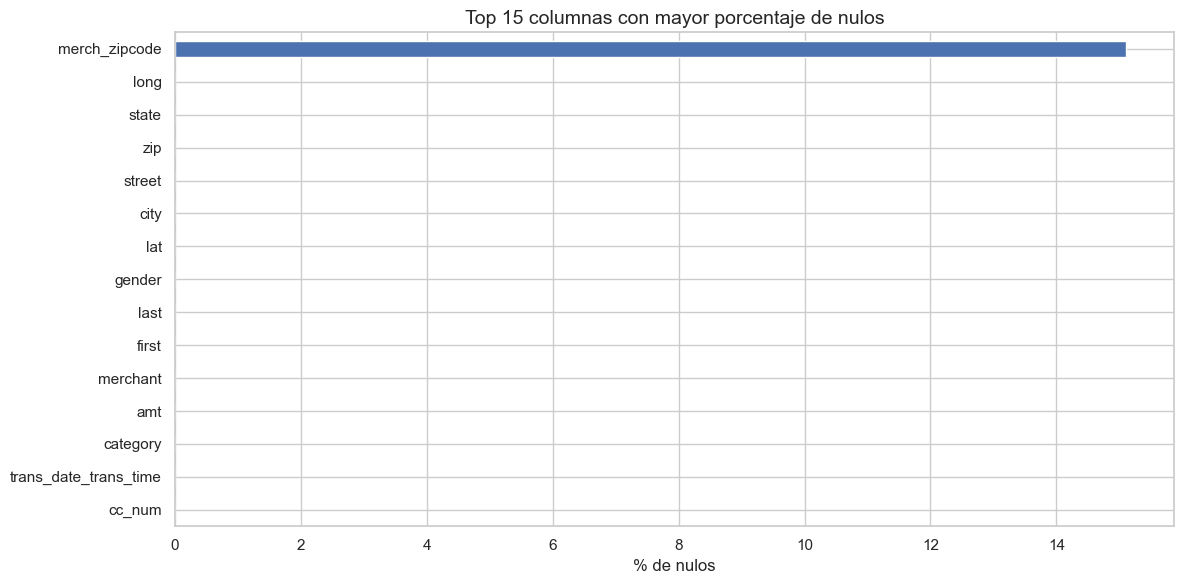

Registros con amt negativo: 0
Registros con fecha/hora invalida: 0


In [4]:
df = df_raw.copy()

# Eliminar indice serializado si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Correccion de tipos
if "trans_date_trans_time" in df.columns:
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
if "dob" in df.columns:
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

df["is_fraud"] = pd.to_numeric(df["is_fraud"], errors="coerce").astype("Int64")
df["amt"] = pd.to_numeric(df["amt"], errors="coerce")

print("Tipos de datos principales:")
display(df.dtypes.sort_index().to_frame("dtype").head(20))

dup_all = df.duplicated().sum()
dup_trans_num = df.duplicated(subset=["trans_num"]).sum() if "trans_num" in df.columns else np.nan

print(f"Duplicados de fila completa: {dup_all:,}")
print(f"Duplicados por trans_num: {dup_trans_num:,}")

null_summary = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("pct_nulos")
      .to_frame()
)

print("\nColumnas con mayor porcentaje de nulos:")
display(null_summary.head(15))

plt.figure(figsize=(12, 5))
null_summary.head(15).sort_values("pct_nulos").plot(kind="barh", legend=False)
plt.title("Top 15 columnas con mayor porcentaje de nulos")
plt.xlabel("% de nulos")
plt.tight_layout()
plt.show()

neg_amt = (df["amt"] < 0).sum()
missing_datetime = df["trans_date_trans_time"].isna().sum()
print(f"Registros con amt negativo: {neg_amt:,}")
print(f"Registros con fecha/hora invalida: {missing_datetime:,}")

Columna de usuario usada: cc_num
Usuarios unicos: 983
Transacciones totales: 1,296,675

Resumen de transacciones por usuario:


,valor
count,983.0000
mean,"1,319.0997"
std,812.2359
min,7.0000
50%,"1,054.0000"
75%,"2,025.0000"
90%,"2,553.8000"
95%,"2,921.6000"
99%,"3,099.3600"
max,"3,123.0000"



Top 15 usuarios con mas transacciones:


,n_transacciones
cc_num,
571365235126,3123
4512828414983801773,3123
36722699017270,3119
213112402583773,3117
3545109339866548,3113
6534628260579800,3112
6011367958204270,3110
2720433095629877,3107
6011438889172900,3106


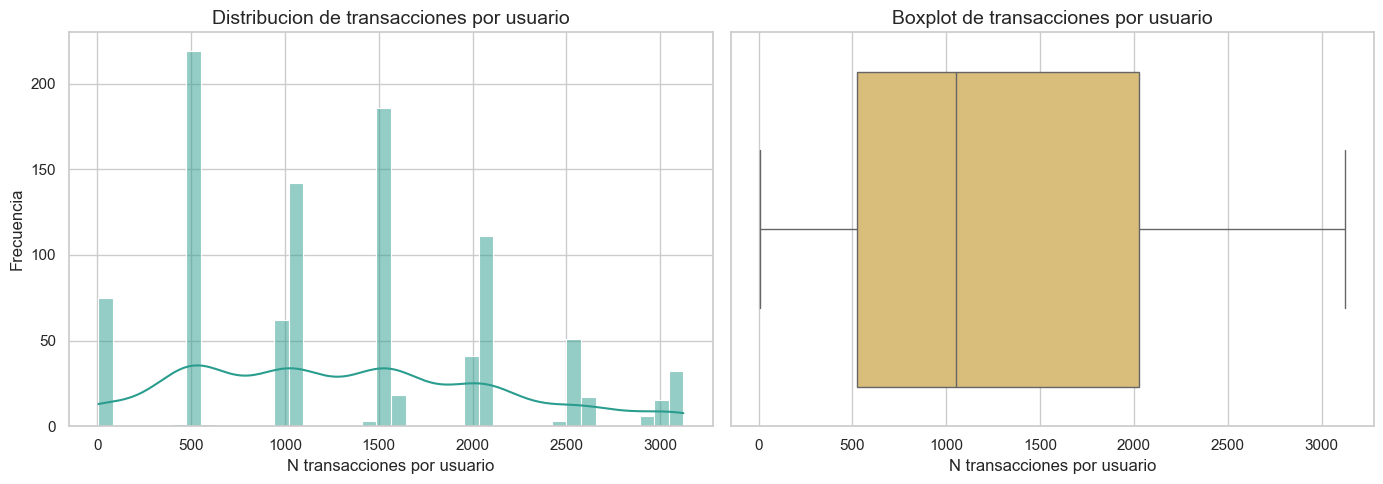

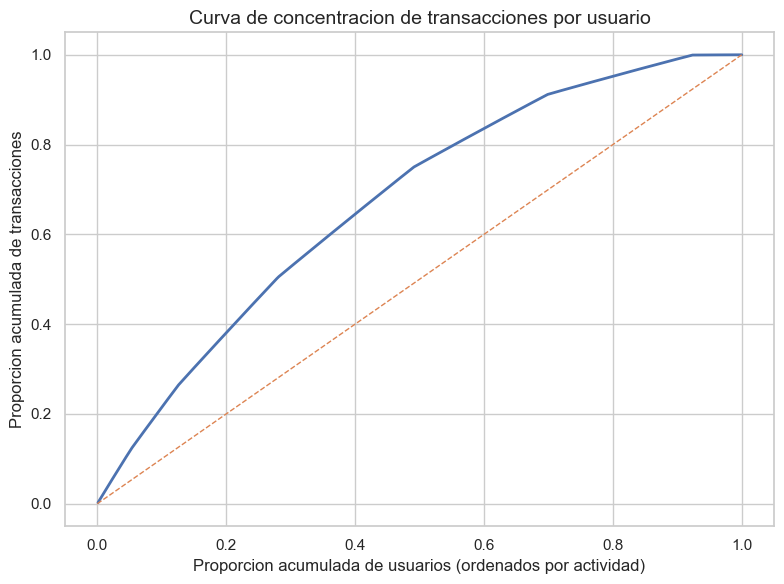

El 10% de usuarios mas activos concentra 21.60% de las transacciones.


In [8]:
user_col = "cc_num"


# Conteo de transacciones por usuario
transactions_per_user = (
    df.groupby(user_col)
      .size()
      .rename("n_transacciones")
      .sort_values(ascending=False)
)

# Resumen numerico para entender el patron general
summary_stats = transactions_per_user.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("valor")
print(f"Columna de usuario usada: {user_col}")
print(f"Usuarios unicos: {transactions_per_user.shape[0]:,}")
print(f"Transacciones totales: {transactions_per_user.sum():,}")
print("\nResumen de transacciones por usuario:")
display(summary_stats)

print("\nTop 15 usuarios con mas transacciones:")
display(transactions_per_user.head(15).to_frame())

# Visualizaciones: histograma + boxplot para ver distribucion y outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(transactions_per_user, bins=40, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribucion de transacciones por usuario")
axes[0].set_xlabel("N transacciones por usuario")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(x=transactions_per_user, ax=axes[1], color="#e9c46a")
axes[1].set_title("Boxplot de transacciones por usuario")
axes[1].set_xlabel("N transacciones por usuario")

plt.tight_layout()
plt.show()

# Curva acumulada para ver concentracion de actividad
cum_share_users = np.arange(1, len(transactions_per_user) + 1) / len(transactions_per_user)
cum_share_tx = transactions_per_user.sort_values(ascending=False).cumsum() / transactions_per_user.sum()

plt.figure(figsize=(8, 6))
plt.plot(cum_share_users, cum_share_tx, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Curva de concentracion de transacciones por usuario")
plt.xlabel("Proporcion acumulada de usuarios (ordenados por actividad)")
plt.ylabel("Proporcion acumulada de transacciones")
plt.tight_layout()
plt.show()

# Indicador simple de concentracion
n_top_10pct = max(1, int(np.ceil(0.10 * len(cum_share_tx))))
top_10pct_users_tx_share = cum_share_tx.iloc[n_top_10pct - 1] * 100
print(f"El 10% de usuarios mas activos concentra {top_10pct_users_tx_share:,.2f}% de las transacciones.")

## 3.1. Distribucion de transacciones por usuario

Se analiza cuantas transacciones registra cada usuario para detectar concentracion, dispersion y posibles patrones de comportamiento.

## 4. Distribución de clases de is_fraud

Se cuantifica el desbalance de clases en conteos absolutos, porcentajes y ratio de desbalance.

,conteo,porcentaje
is_fraud,,
0,1289169,99.4211
1,7506,0.5789


No fraude: 1,289,169
Fraude: 7,506
Ratio no_fraude/fraude: 171.75


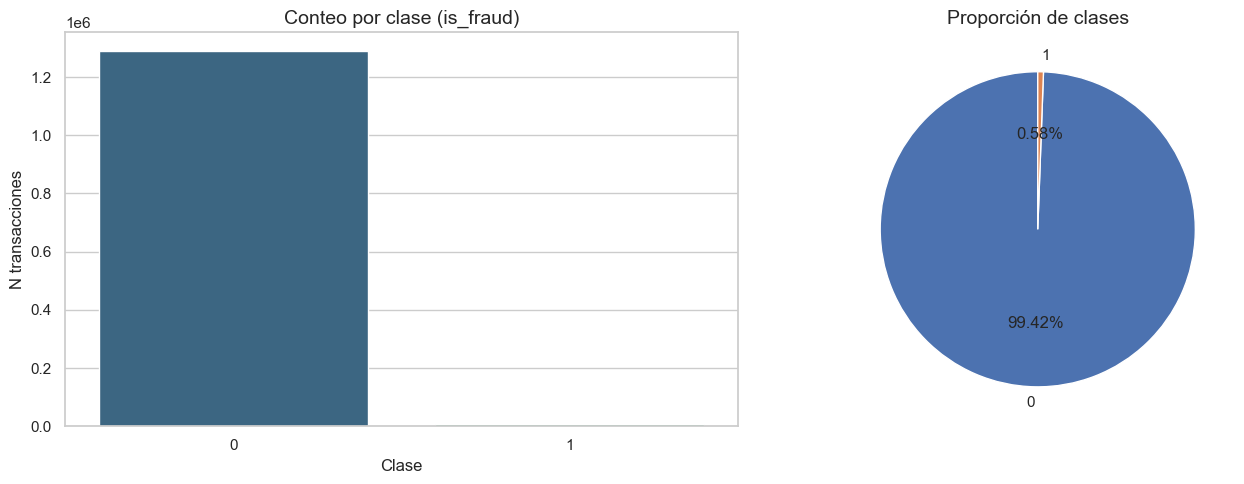

In [6]:
class_counts = df["is_fraud"].value_counts(dropna=False).sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(4)

class_dist = pd.DataFrame({
    "conteo": class_counts,
    "porcentaje": class_pct
})

display(class_dist)

n_nonfraud = int(class_counts.get(0, 0))
n_fraud = int(class_counts.get(1, 0))
imbalance_ratio = np.inf if n_fraud == 0 else n_nonfraud / n_fraud

print(f"No fraude: {n_nonfraud:,}")
print(f"Fraude: {n_fraud:,}")
print(f"Ratio no_fraude/fraude: {imbalance_ratio:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Conteo por clase (is_fraud)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("N transacciones")

axes[1].pie(class_counts.values, labels=[str(i) for i in class_counts.index], autopct="%1.2f%%", startangle=90)
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.show()

## 5. Análisis temporal de transacciones

Se generan variables temporales y se analiza volumen total, volumen fraudulento y tasa de fraude por distintos cortes de tiempo.

,transacciones,fraudes,tasa_fraude
trans_date_trans_time,,,
2019-07-31,86596,331,0.0038
2019-08-31,87359,382,0.0044
2019-09-30,70652,418,0.0059
2019-10-31,68758,454,0.0066
2019-11-30,70421,388,0.0055
2019-12-31,141060,592,0.0042
2020-01-31,52202,343,0.0066
2020-02-29,47791,336,0.0070
2020-03-31,72850,444,0.0061


,transacciones,fraudes,tasa_fraude
hour,,,
0,42502,635,0.0149
1,42869,658,0.0153
2,42656,625,0.0147
3,42769,609,0.0142
4,41863,46,0.0011


,transacciones,fraudes,tasa_fraude
weekday_name,,,
Monday,254282,1182,0.0046
Tuesday,160227,935,0.0058
Wednesday,131073,859,0.0066
Thursday,147285,1008,0.0068
Friday,152272,1079,0.0071
Saturday,200957,1227,0.0061
Sunday,250579,1216,0.0049


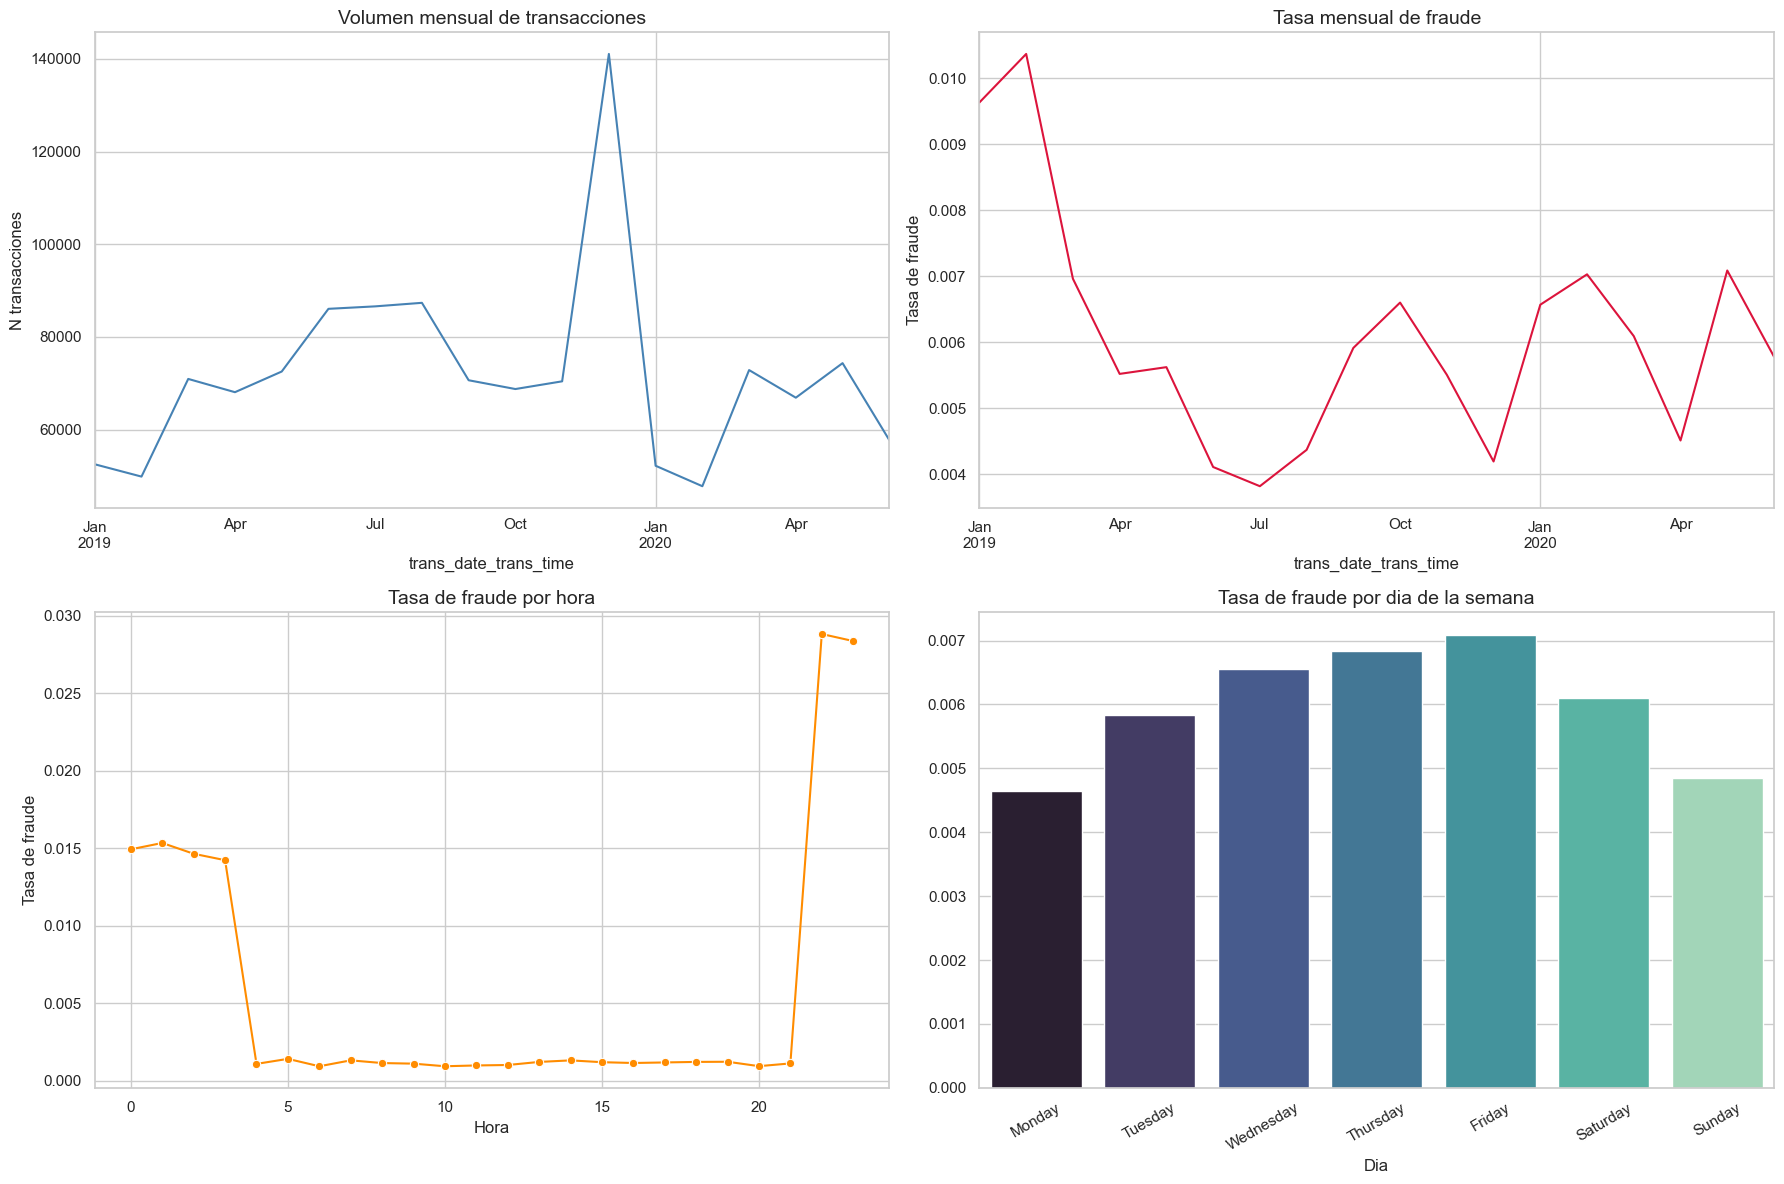

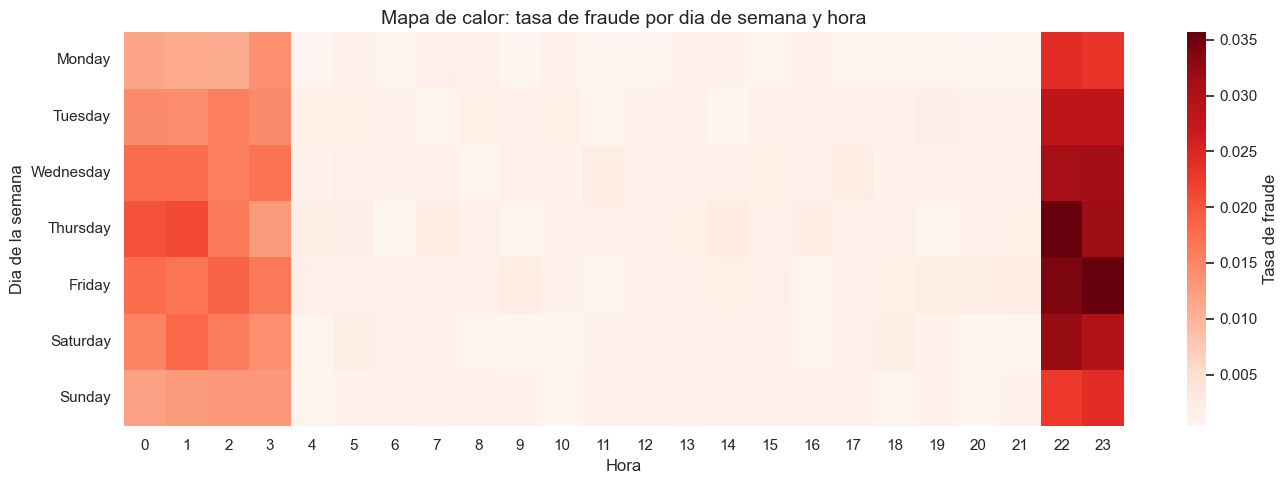

In [7]:
# Ingenieria temporal

df = df.sort_values("trans_date_trans_time").copy()

df["year"] = df["trans_date_trans_time"].dt.year
df["month"] = df["trans_date_trans_time"].dt.month
df["day"] = df["trans_date_trans_time"].dt.day
df["hour"] = df["trans_date_trans_time"].dt.hour
df["weekday"] = df["trans_date_trans_time"].dt.dayofweek
df["weekday_name"] = df["trans_date_trans_time"].dt.day_name()
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

df_time = df.dropna(subset=["trans_date_trans_time"]).set_index("trans_date_trans_time")

monthly = df_time["is_fraud"].resample("ME").agg(transacciones="count", fraudes="sum")
monthly["tasa_fraude"] = monthly["fraudes"] / monthly["transacciones"]

hourly = df.groupby("hour")["is_fraud"].agg(transacciones="count", fraudes="sum")
hourly["tasa_fraude"] = hourly["fraudes"] / hourly["transacciones"]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = df.groupby("weekday_name")["is_fraud"].agg(transacciones="count", fraudes="sum")
weekly["tasa_fraude"] = weekly["fraudes"] / weekly["transacciones"]
weekly = weekly.reindex(weekday_order)

heatmap_data = (
    df.pivot_table(index="weekday_name", columns="hour", values="is_fraud", aggfunc="mean")
      .reindex(weekday_order)
)

# Forzar tipo numerico para evitar errores de visualizacion con dtypes object
heatmap_data = heatmap_data.apply(pd.to_numeric, errors="coerce").astype(float)

display(monthly.tail(12))
display(hourly.head())
display(weekly)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

monthly["transacciones"].plot(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Volumen mensual de transacciones")
axes[0, 0].set_ylabel("N transacciones")

monthly["tasa_fraude"].plot(ax=axes[0, 1], color="crimson")
axes[0, 1].set_title("Tasa mensual de fraude")
axes[0, 1].set_ylabel("Tasa de fraude")

sns.lineplot(x=hourly.index, y=hourly["tasa_fraude"], marker="o", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Tasa de fraude por hora")
axes[1, 0].set_xlabel("Hora")
axes[1, 0].set_ylabel("Tasa de fraude")

sns.barplot(x=weekly.index, y=weekly["tasa_fraude"].values, ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Tasa de fraude por dia de la semana")
axes[1, 1].set_xlabel("Dia")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="Reds", cbar_kws={"label": "Tasa de fraude"})
plt.title("Mapa de calor: tasa de fraude por dia de semana y hora")
plt.xlabel("Hora")
plt.ylabel("Dia de la semana")
plt.tight_layout()
plt.show()

## 6. Medidas de tendencia central y dispersión de amt

Se calculan métricas globales y por clase para comparar comportamiento monetario entre fraude y no fraude.

In [8]:
def resumen_amt(s: pd.Series) -> pd.Series:
    s = s.dropna()
    moda = s.mode().iloc[0] if not s.mode().empty else np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return pd.Series({
        "count": s.count(),
        "media": s.mean(),
        "mediana": s.median(),
        "moda": moda,
        "std": s.std(),
        "min": s.min(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "skew": s.skew()
    })

res_global_amt = resumen_amt(df["amt"]).to_frame("global")
print("Resumen global de amt:")
display(res_global_amt)

res_por_clase = df.groupby("is_fraud", dropna=False)["amt"].apply(resumen_amt).unstack(1)
print("Resumen de amt por is_fraud:")
display(res_por_clase)

comparison = pd.DataFrame({
    "media_no_fraude": [res_por_clase.loc[0, "media"] if 0 in res_por_clase.index else np.nan],
    "media_fraude": [res_por_clase.loc[1, "media"] if 1 in res_por_clase.index else np.nan],
    "mediana_no_fraude": [res_por_clase.loc[0, "mediana"] if 0 in res_por_clase.index else np.nan],
    "mediana_fraude": [res_por_clase.loc[1, "mediana"] if 1 in res_por_clase.index else np.nan]
})
comparison["ratio_media_fraude_vs_no_fraude"] = comparison["media_fraude"] / comparison["media_no_fraude"]
comparison["ratio_mediana_fraude_vs_no_fraude"] = comparison["mediana_fraude"] / comparison["mediana_no_fraude"]

print("Comparativos de tendencia central:")
display(comparison.T)

Resumen global de amt:


,global
count,"1,296,675.0000"
media,70.3510
mediana,47.5200
moda,1.1400
std,160.3160
min,1.0000
q1,9.6500
q3,83.1400
iqr,73.4900
p95,196.3100


Resumen de amt por is_fraud:


,count,media,mediana,moda,std,min,q1,q3,iqr,p95,p99,max,skew
is_fraud,,,,,,,,,,,,,
0,"1,289,169.0000",67.6671,47.2800,1.1400,154.0080,1.0000,9.6100,82.5400,72.9300,189.9000,486.3032,"28,948.9000",47.5238
1,"7,506.0000",531.3201,396.5050,8.7500,390.5601,1.0600,245.6625,900.8750,655.2125,"1,083.9850","1,179.6900","1,376.0400",0.0258


Comparativos de tendencia central:


,0
media_no_fraude,67.6671
media_fraude,531.3201
mediana_no_fraude,47.2800
mediana_fraude,396.5050
ratio_media_fraude_vs_no_fraude,7.8520
ratio_mediana_fraude_vs_no_fraude,8.3863


## 7. Distribución de amt (global y por clase)

Se visualiza la distribución de `amt` en escala normal y logarítmica, incluyendo comparaciones por clase.

Nota: para gráficos costosos se usa muestreo para mantener buen rendimiento.

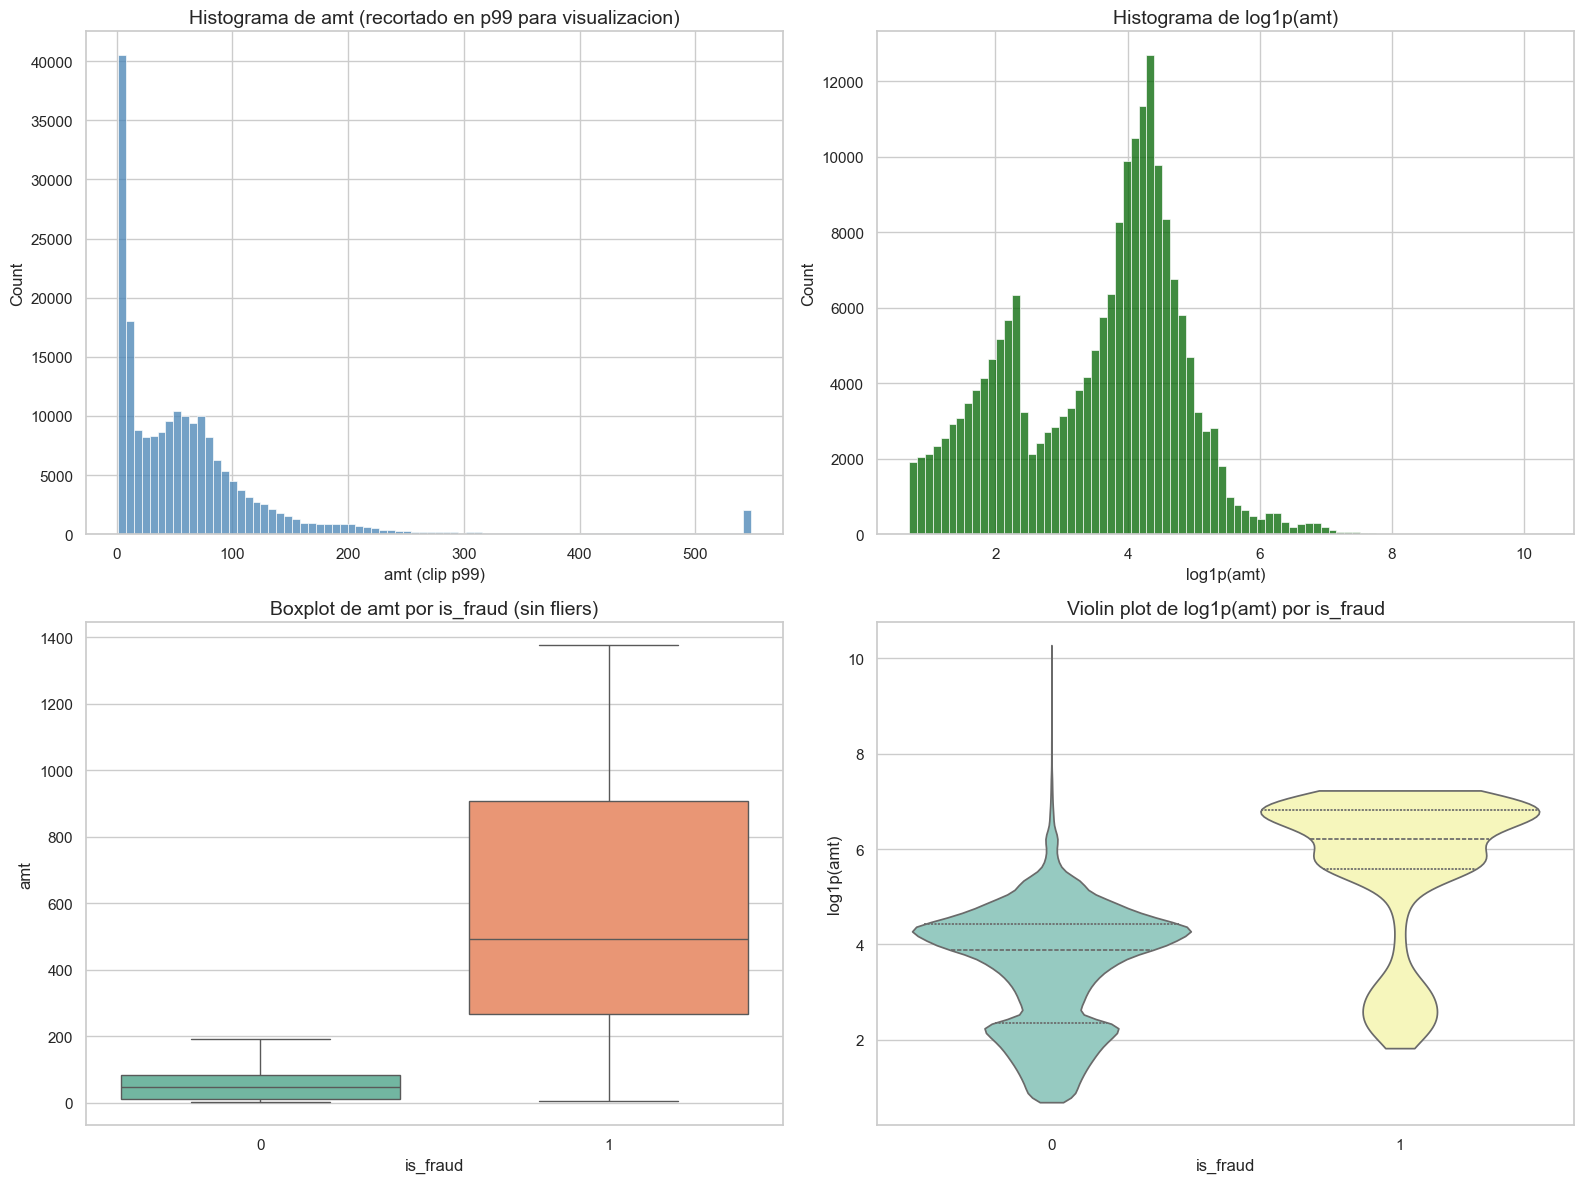

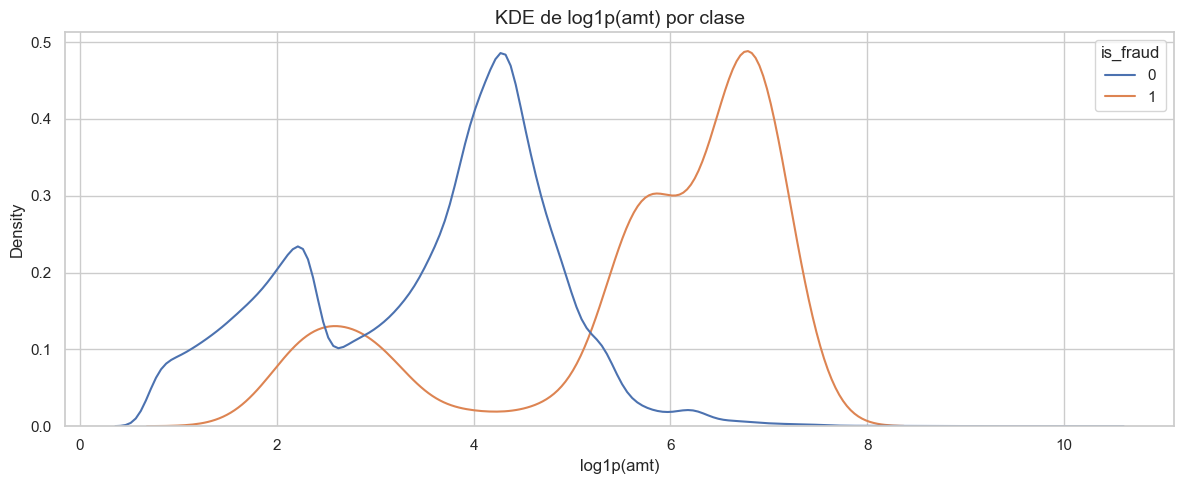

In [9]:
plot_sample_n = min(len(df), 200_000)
plot_df = df.sample(plot_sample_n, random_state=42) if len(df) > plot_sample_n else df.copy()

plot_df = plot_df.copy()
plot_df["log_amt"] = np.log1p(plot_df["amt"].clip(lower=0))
plot_df["amt_clip_p99"] = plot_df["amt"].clip(upper=plot_df["amt"].quantile(0.99))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(data=plot_df, x="amt_clip_p99", bins=80, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Histograma de amt (recortado en p99 para visualizacion)")
axes[0, 0].set_xlabel("amt (clip p99)")

sns.histplot(data=plot_df, x="log_amt", bins=80, ax=axes[0, 1], color="darkgreen")
axes[0, 1].set_title("Histograma de log1p(amt)")
axes[0, 1].set_xlabel("log1p(amt)")

sns.boxplot(data=plot_df, x="is_fraud", y="amt", showfliers=False, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Boxplot de amt por is_fraud (sin fliers)")
axes[1, 0].set_xlabel("is_fraud")
axes[1, 0].set_ylabel("amt")

sns.violinplot(data=plot_df, x="is_fraud", y="log_amt", cut=0, inner="quartile", ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Violin plot de log1p(amt) por is_fraud")
axes[1, 1].set_xlabel("is_fraud")
axes[1, 1].set_ylabel("log1p(amt)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.kdeplot(data=plot_df, x="log_amt", hue="is_fraud", common_norm=False)
plt.title("KDE de log1p(amt) por clase")
plt.xlabel("log1p(amt)")
plt.tight_layout()
plt.show()

## 8. Outliers y comportamiento extremo en amt

Se detectan outliers con IQR y percentiles altos, y se evalúa su relación con fraude.

Q1: 9.6500 | Q3: 83.1400 | IQR: 73.4900 | Umbral superior IQR: 193.3750

Resumen de fraude en outliers IQR:


,transacciones,fraudes,tasa_fraude
amt_outlier_iqr,,,
0,1229385,1801,0.0015
1,67290,5705,0.0848



Percentiles altos de amt:


,amt
0.9500,196.3100
0.9900,545.9926
0.9990,"1,499.2543"


Fraude en cola superior de montos:


,segmento,n,fraudes,tasa_fraude
0,amt >= p95,64835,5705,0.0880
1,amt >= p99,12967,3600,0.2776
2,amt >= p999,1297,0,0.0000


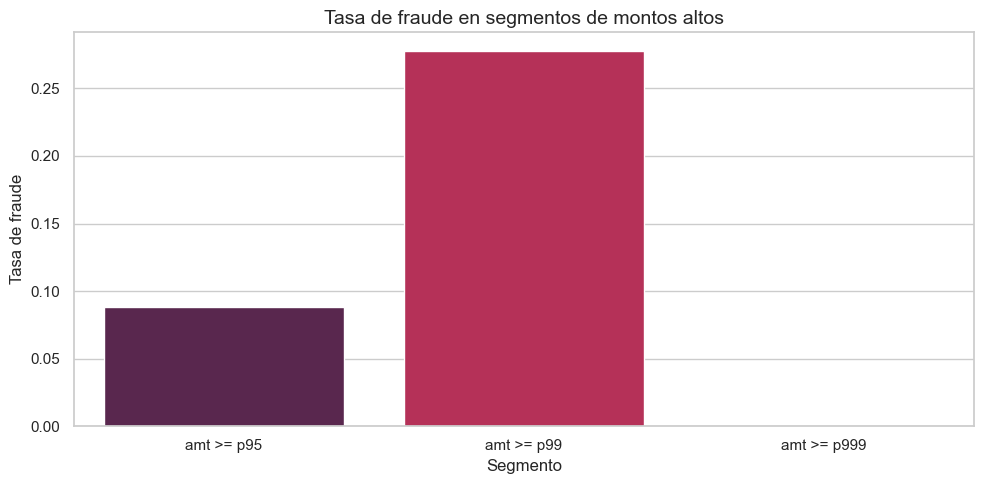

In [10]:
q1 = df["amt"].quantile(0.25)
q3 = df["amt"].quantile(0.75)
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

df["amt_outlier_iqr"] = (df["amt"] > upper_iqr).astype(int)

outlier_summary = df.groupby("amt_outlier_iqr")["is_fraud"].agg(transacciones="count", fraudes="sum")
outlier_summary["tasa_fraude"] = outlier_summary["fraudes"] / outlier_summary["transacciones"]

percentiles = df["amt"].quantile([0.95, 0.99, 0.999]).to_frame("amt")

print(f"Q1: {q1:,.4f} | Q3: {q3:,.4f} | IQR: {iqr:,.4f} | Umbral superior IQR: {upper_iqr:,.4f}")
print("\nResumen de fraude en outliers IQR:")
display(outlier_summary)
print("\nPercentiles altos de amt:")
display(percentiles)

thresholds = {
    "p95": df["amt"].quantile(0.95),
    "p99": df["amt"].quantile(0.99),
    "p999": df["amt"].quantile(0.999)
}

rows = []
for name, thr in thresholds.items():
    mask = df["amt"] >= thr
    rows.append({
        "segmento": f"amt >= {name}",
        "n": int(mask.sum()),
        "fraudes": int(df.loc[mask, "is_fraud"].sum()),
        "tasa_fraude": float(df.loc[mask, "is_fraud"].mean())
    })

extreme_amt = pd.DataFrame(rows)
print("Fraude en cola superior de montos:")
display(extreme_amt)

plt.figure(figsize=(10, 5))
sns.barplot(data=extreme_amt, x="segmento", y="tasa_fraude", palette="rocket")
plt.title("Tasa de fraude en segmentos de montos altos")
plt.ylabel("Tasa de fraude")
plt.xlabel("Segmento")
plt.tight_layout()
plt.show()

## 9. Análisis bivariado de variables clave vs is_fraud

Se comparan tasas de fraude por variables categóricas y de comportamiento relevantes para el modelado.


Top riesgo por category:


,transacciones,fraudes,tasa_fraude
category,,,
shopping_net,97543,1713,0.0176
misc_net,63287,915,0.0145
grocery_pos,123638,1743,0.0141
shopping_pos,116672,843,0.0072
gas_transport,131659,618,0.0047
misc_pos,79655,250,0.0031
grocery_net,45452,134,0.0029
travel,40507,116,0.0029
entertainment,94014,233,0.0025



Top riesgo por state:


,transacciones,fraudes,tasa_fraude
state,,,
AK,2120,36,0.0170
NV,5607,47,0.0084
CO,13880,113,0.0081
OR,18597,149,0.0080
TN,17554,140,0.0080
NE,24168,180,0.0074
ME,16505,119,0.0072
NH,8278,59,0.0071
OH,46480,321,0.0069



Top riesgo por gender:


,transacciones,fraudes,tasa_fraude
gender,,,
M,586812,3771,0.0064
F,709863,3735,0.0053



Tasa de fraude por franja horaria:


,transacciones,fraudes,tasa_fraude
hour_band,,,
noche,396276,4133,0.0104
madrugada,254830,2633,0.0103
tarde,392023,466,0.0012
manana,253546,274,0.0011


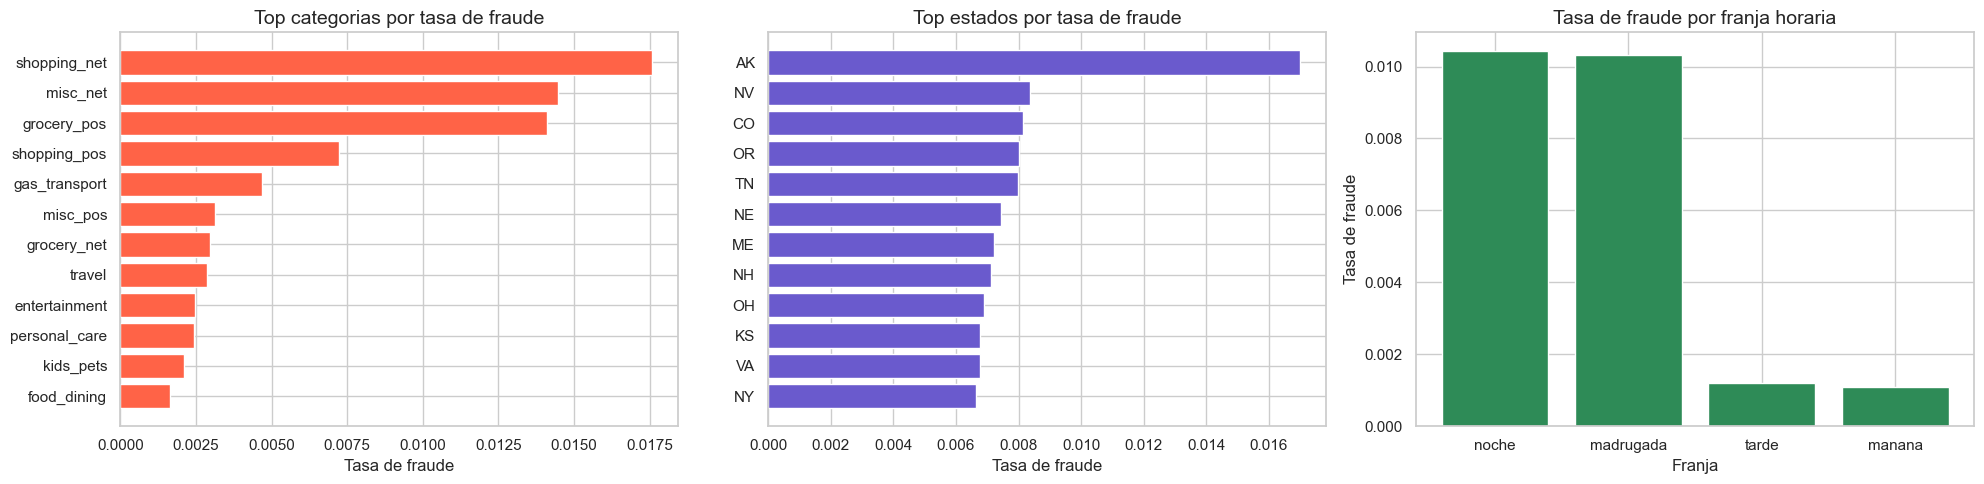


Top 10 tarjetas con mas fraudes (con al menos 20 transacciones):


,tx_count,fraud_count,unique_merchants,avg_amt,fraud_rate
cc_num,,,,,
3520550088202337,989,19,503,80.6711,0.0192
4260128500325,1466,18,580,73.7162,0.0123
4629451965224809,1531,16,592,52.7958,0.0105
6011366578560244,2060,16,630,53.7543,0.0078
4874006077381178,516,16,340,65.8534,0.0310
3518669219150142,2525,16,660,51.6355,0.0063
3556613125071656,2556,16,669,52.1480,0.0063
3576021480694169,2527,16,660,50.2980,0.0063
30074693890476,2057,16,624,90.2898,0.0078



Top 10 comercios con mayor tasa de fraude (con al menos 200 transacciones):


,tx_count,fraud_count,avg_amt,fraud_rate
merchant,,,,
fraud_Kozey-Boehm,1866,48,98.2381,0.0257
"fraud_Herman, Treutel and Dickens",1300,33,87.0619,0.0254
fraud_Kerluke-Abshire,1838,41,98.0354,0.0223
fraud_Brown PLC,1176,26,89.8480,0.0221
fraud_Goyette Inc,1943,42,93.9126,0.0216
fraud_Terry-Huel,1996,43,93.2821,0.0215
fraud_Jast Ltd,1953,42,90.3868,0.0215
"fraud_Schmeler, Bashirian and Price",1968,41,96.7184,0.0208
fraud_Boyer-Reichert,1908,38,89.7331,0.0199


In [11]:
def tabla_tasa_fraude(dataframe, col, min_count=1000):
    t = dataframe.groupby(col)["is_fraud"].agg(transacciones="count", fraudes="sum")
    t["tasa_fraude"] = t["fraudes"] / t["transacciones"]
    t = t[t["transacciones"] >= min_count].sort_values("tasa_fraude", ascending=False)
    return t

cat_cols = [c for c in ["category", "state", "gender"] if c in df.columns]

resultados_cat = {}
for col in cat_cols:
    resultados_cat[col] = tabla_tasa_fraude(df, col, min_count=1000)
    print(f"\nTop riesgo por {col}:")
    display(resultados_cat[col].head(15))

# Riesgo por combinacion temporal
hour_band = pd.cut(df["hour"], bins=[-1, 5, 11, 17, 23], labels=["madrugada", "manana", "tarde", "noche"])
tmp = df.assign(hour_band=hour_band)
rate_hour_band = tabla_tasa_fraude(tmp, "hour_band", min_count=1000)
print("\nTasa de fraude por franja horaria:")
display(rate_hour_band)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

if "category" in resultados_cat and not resultados_cat["category"].empty:
    top_cat = resultados_cat["category"].head(12).sort_values("tasa_fraude", ascending=True)
    axes[0].barh(top_cat.index, top_cat["tasa_fraude"], color="tomato")
    axes[0].set_title("Top categorias por tasa de fraude")
    axes[0].set_xlabel("Tasa de fraude")
else:
    axes[0].text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center")
    axes[0].set_title("Top categorias")

if "state" in resultados_cat and not resultados_cat["state"].empty:
    top_state = resultados_cat["state"].head(12).sort_values("tasa_fraude", ascending=True)
    axes[1].barh(top_state.index, top_state["tasa_fraude"], color="slateblue")
    axes[1].set_title("Top estados por tasa de fraude")
    axes[1].set_xlabel("Tasa de fraude")
else:
    axes[1].text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center")
    axes[1].set_title("Top estados")

if not rate_hour_band.empty:
    axes[2].bar(rate_hour_band.index.astype(str), rate_hour_band["tasa_fraude"], color="seagreen")
    axes[2].set_title("Tasa de fraude por franja horaria")
    axes[2].set_xlabel("Franja")
    axes[2].set_ylabel("Tasa de fraude")
else:
    axes[2].text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center")
    axes[2].set_title("Franja horaria")

plt.tight_layout()
plt.show()

# Analisis de comportamiento por tarjeta y comercio
card_stats = df.groupby("cc_num").agg(
    tx_count=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum"),
    unique_merchants=("merchant", "nunique"),
    avg_amt=("amt", "mean")
)
card_stats["fraud_rate"] = card_stats["fraud_count"] / card_stats["tx_count"]

merchant_stats = df.groupby("merchant").agg(
    tx_count=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum"),
    avg_amt=("amt", "mean")
)
merchant_stats["fraud_rate"] = merchant_stats["fraud_count"] / merchant_stats["tx_count"]

print("\nTop 10 tarjetas con mas fraudes (con al menos 20 transacciones):")
display(card_stats[card_stats["tx_count"] >= 20].sort_values("fraud_count", ascending=False).head(10))

print("\nTop 10 comercios con mayor tasa de fraude (con al menos 200 transacciones):")
display(merchant_stats[merchant_stats["tx_count"] >= 200].sort_values("fraud_rate", ascending=False).head(10))

## 10. Correlaciones y multicolinealidad

Se calcula matriz de correlación para variables numéricas y se identifican asociaciones relevantes con `is_fraud`.

Variables numericas con mayor correlacion absoluta con is_fraud:


,corr_con_is_fraud
amt_outlier_iqr,0.2436
amt,0.2194
hour,0.0138
month,-0.0124
unix_time,-0.0051
day,0.0038
is_weekend,-0.0036
year,0.0030
city_pop,0.0021
lat,0.0019


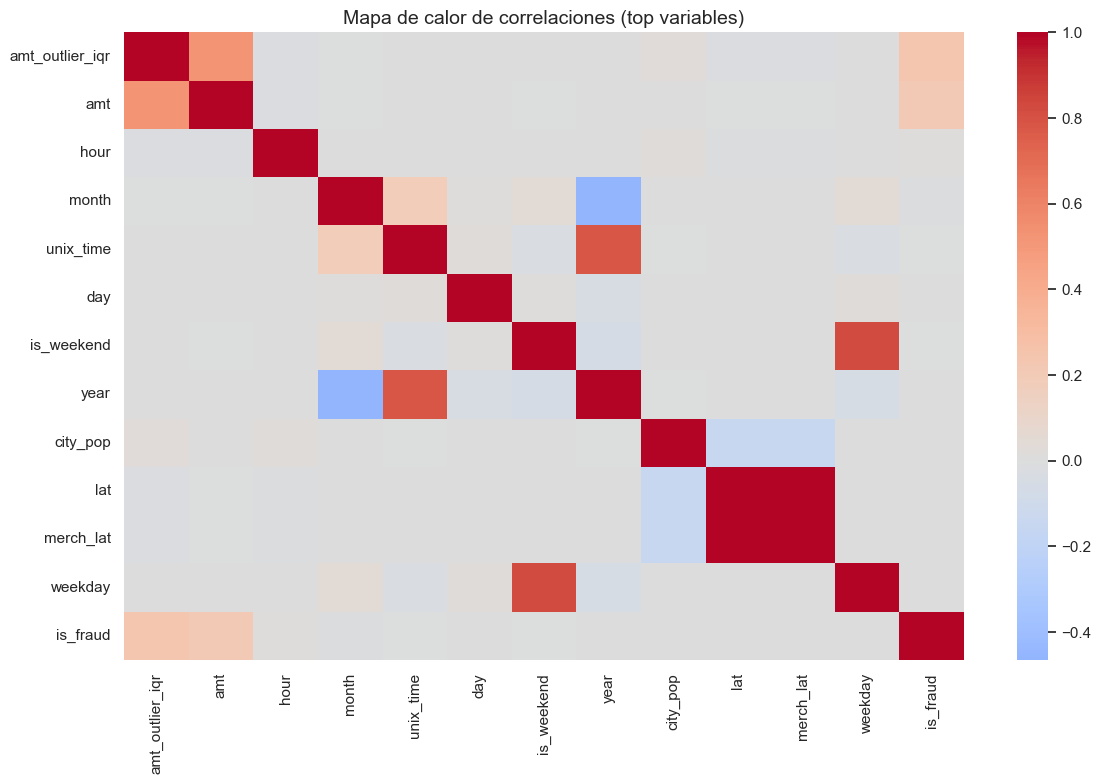

Pares con |corr| >= 0.85:


,var_1,var_2,corr
1,long,merch_long,0.9991
0,lat,merch_lat,0.9936


In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir identificadores casi unicos para no distorsionar correlacion
exclude_like_id = [c for c in ["cc_num", "zip", "merch_zipcode", "trans_num"] if c in numeric_cols]
numeric_for_corr = [c for c in numeric_cols if c not in exclude_like_id]

corr = df[numeric_for_corr].corr(numeric_only=True)

if "is_fraud" in corr.columns:
    corr_is_fraud = corr["is_fraud"].drop("is_fraud").sort_values(key=lambda s: s.abs(), ascending=False)
    print("Variables numericas con mayor correlacion absoluta con is_fraud:")
    display(corr_is_fraud.to_frame("corr_con_is_fraud").head(15))

plt.figure(figsize=(12, 8))
# Top variables por correlacion absoluta con fraude para un heatmap legible
if "is_fraud" in corr.columns:
    top_vars = corr_is_fraud.head(12).index.tolist() + ["is_fraud"]
    corr_top = df[top_vars].corr(numeric_only=True)
else:
    corr_top = corr

sns.heatmap(corr_top, cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones (top variables)")
plt.tight_layout()
plt.show()

# Pares con alta multicolinealidad
thr = 0.85
high_corr_pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr.iloc[i, j]
        if pd.notna(val) and abs(val) >= thr:
            high_corr_pairs.append((cols[i], cols[j], val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["var_1", "var_2", "corr"])
print(f"Pares con |corr| >= {thr}:")
display(high_corr_df.sort_values("corr", key=lambda s: s.abs(), ascending=False).head(20))

## 11. Segmentación temporal y riesgo de fuga de información

Se propone una partición train/valid/test basada en tiempo para evitar leakage en fraude transaccional.

In [13]:
df_time_sorted = df.dropna(subset=["trans_date_trans_time"]).sort_values("trans_date_trans_time").copy()

n = len(df_time_sorted)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train = df_time_sorted.iloc[:train_end]
valid = df_time_sorted.iloc[train_end:valid_end]
test = df_time_sorted.iloc[valid_end:]

split_summary = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "n": [len(train), len(valid), len(test)],
    "inicio": [train["trans_date_trans_time"].min(), valid["trans_date_trans_time"].min(), test["trans_date_trans_time"].min()],
    "fin": [train["trans_date_trans_time"].max(), valid["trans_date_trans_time"].max(), test["trans_date_trans_time"].max()],
    "fraudes": [train["is_fraud"].sum(), valid["is_fraud"].sum(), test["is_fraud"].sum()]
})
split_summary["tasa_fraude"] = split_summary["fraudes"] / split_summary["n"]

display(split_summary)

leakage_candidates = [
    "trans_num",      # ID unico de transaccion
    "unix_time",      # timestamp crudo; usar con cuidado para evitar sobreajuste temporal
    "merch_lat", "merch_long", "lat", "long",  # variables geograficas potencialmente sensibles
    "dob"             # recomendable convertir a edad al momento de transaccion
]

present_leakage_candidates = [c for c in leakage_candidates if c in df.columns]
print("Columnas a revisar por posible leakage o sobreajuste:")
print(present_leakage_candidates)

print("\nRecomendacion de pipeline de modelado:")
print("1) Crear features historicas solo con informacion disponible hasta cada transaccion.")
print("2) Validar por ventanas temporales, no con split aleatorio puro.")
print("3) Tratar desbalance con class_weight, focal loss o muestreo en train.")

,split,n,inicio,fin,fraudes,tasa_fraude
0,train,907672,2019-01-01 00:00:18,2019-12-28 17:18:24,5121,0.0056
1,valid,194501,2019-12-28 17:18:38,2020-04-03 17:53:52,1252,0.0064
2,test,194502,2020-04-03 17:54:44,2020-06-21 12:13:37,1133,0.0058


Columnas a revisar por posible leakage o sobreajuste:
['trans_num', 'unix_time', 'merch_lat', 'merch_long', 'lat', 'long', 'dob']

Recomendacion de pipeline de modelado:
1) Crear features historicas solo con informacion disponible hasta cada transaccion.
2) Validar por ventanas temporales, no con split aleatorio puro.
3) Tratar desbalance con class_weight, focal loss o muestreo en train.


## 12. Resumen de hallazgos accionables para predicción de fraude

Checklist recomendado para el siguiente notebook de modelado:

1. **Desbalance de clases:** usar métricas robustas (PR-AUC, F1, recall@k) y estrategias de balanceo solo en train.
2. **Temporalidad:** conservar validación temporal y monitorear drift por mes/hora/weekday.
3. **Monto (`amt`):** usar transformaciones robustas (`log1p`, clipping/winsorization según experimento) y conservar señal de outliers.
4. **Variables operativas de alto valor:** `category`, `state`, `hour`, `is_weekend`, features de comportamiento por tarjeta/comercio.
5. **Prevención de leakage:** excluir IDs y columnas post-evento; crear features históricas con ventanas causales.
6. **Siguiente paso sugerido:** baseline con `LightGBM/XGBoost` o `CatBoost` + calibración de umbral por costo de fraude.

In [7]:
# Resumen compacto de metricas para interpretacion ejecutiva
import numpy as np
import pandas as pd

# 1) Calidad de datos
print("=== CALIDAD DE DATOS ===")
print({
    "n_filas": int(len(df)),
    "n_columnas": int(df.shape[1]),
    "duplicados_fila": int(df.duplicated().sum()),
    "duplicados_trans_num": int(df.duplicated(subset=["trans_num"]).sum()) if "trans_num" in df.columns else None,
    "pct_nulo_merch_zipcode": float(df["merch_zipcode"].isna().mean() * 100) if "merch_zipcode" in df.columns else None,
    "amt_negativos": int((df["amt"] < 0).sum()) if "amt" in df.columns else None,
})

# 2) Distribucion por usuario
user_col = "cc_num" if "cc_num" in df.columns else None
if user_col:
    tpu = df.groupby(user_col).size().sort_values(ascending=False)
    n_top10 = max(1, int(np.ceil(0.10 * len(tpu))))
    top10_share = float(tpu.iloc[:n_top10].sum() / tpu.sum())
    print("\n=== TRANSACCIONES POR USUARIO ===")
    print({
        "usuarios_unicos": int(tpu.shape[0]),
        "tx_totales": int(tpu.sum()),
        "tx_por_usuario_mediana": float(tpu.median()),
        "tx_por_usuario_p95": float(tpu.quantile(0.95)),
        "tx_por_usuario_max": int(tpu.max()),
        "share_top10pct_usuarios": round(top10_share, 4),
    })

# 3) Clases
class_counts = df["is_fraud"].value_counts().sort_index()
fraud_rate = float(class_counts.get(1, 0) / class_counts.sum())
print("\n=== CLASES FRAUDE ===")
print({
    "no_fraude": int(class_counts.get(0, 0)),
    "fraude": int(class_counts.get(1, 0)),
    "tasa_fraude_global": round(fraud_rate, 6),
    "ratio_no_fraude_fraude": round(float(class_counts.get(0, 0) / max(class_counts.get(1, 1), 1)), 2),
})

# 4) Temporalidad
df_tmp = df.copy()
df_tmp["trans_date_trans_time"] = pd.to_datetime(df_tmp["trans_date_trans_time"], errors="coerce")
df_tmp = df_tmp.dropna(subset=["trans_date_trans_time"])
df_tmp["hour"] = df_tmp["trans_date_trans_time"].dt.hour
df_tmp["weekday_name"] = df_tmp["trans_date_trans_time"].dt.day_name()
df_tmp["month_period"] = df_tmp["trans_date_trans_time"].dt.to_period("M")

monthly = df_tmp.groupby("month_period")["is_fraud"].agg(transacciones="count", fraudes="sum")
monthly["tasa_fraude"] = monthly["fraudes"] / monthly["transacciones"]

hourly_rate = df_tmp.groupby("hour")["is_fraud"].mean()
wd_rate = df_tmp.groupby("weekday_name")["is_fraud"].mean()

print("\n=== TEMPORALIDAD ===")
print({
    "mes_max_volumen": str(monthly["transacciones"].idxmax()),
    "max_volumen_mensual": int(monthly["transacciones"].max()),
    "mes_min_tasa_fraude": str(monthly["tasa_fraude"].idxmin()),
    "min_tasa_fraude_mensual": round(float(monthly["tasa_fraude"].min()), 6),
    "mes_max_tasa_fraude": str(monthly["tasa_fraude"].idxmax()),
    "max_tasa_fraude_mensual": round(float(monthly["tasa_fraude"].max()), 6),
    "hora_max_tasa": int(hourly_rate.idxmax()),
    "max_tasa_hora": round(float(hourly_rate.max()), 6),
    "hora_min_tasa": int(hourly_rate.idxmin()),
    "min_tasa_hora": round(float(hourly_rate.min()), 6),
    "dia_max_tasa": str(wd_rate.idxmax()),
    "tasa_dia_max": round(float(wd_rate.max()), 6),
})

# 5) Montos por clase
amt_by_class = df.groupby("is_fraud")["amt"].agg(["mean", "median", "std", "quantile"])
mean0 = float(df.loc[df["is_fraud"] == 0, "amt"].mean())
mean1 = float(df.loc[df["is_fraud"] == 1, "amt"].mean())
med0 = float(df.loc[df["is_fraud"] == 0, "amt"].median())
med1 = float(df.loc[df["is_fraud"] == 1, "amt"].median())

print("\n=== MONTOS POR CLASE ===")
print({
    "media_no_fraude": round(mean0, 2),
    "media_fraude": round(mean1, 2),
    "ratio_media_f_vs_nf": round(mean1 / mean0, 2) if mean0 else None,
    "mediana_no_fraude": round(med0, 2),
    "mediana_fraude": round(med1, 2),
    "ratio_mediana_f_vs_nf": round(med1 / med0, 2) if med0 else None,
})

# 6) Outliers de monto
q1 = df["amt"].quantile(0.25)
q3 = df["amt"].quantile(0.75)
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr
mask_out = df["amt"] > upper_iqr

p95 = df["amt"].quantile(0.95)
p99 = df["amt"].quantile(0.99)
p999 = df["amt"].quantile(0.999)

def seg_rate(mask):
    if mask.sum() == 0:
        return 0.0
    return float(df.loc[mask, "is_fraud"].mean())

print("\n=== OUTLIERS Y COLA ALTA ===")
print({
    "umbral_iqr_superior": round(float(upper_iqr), 2),
    "pct_outliers_iqr": round(float(mask_out.mean() * 100), 3),
    "tasa_fraude_outliers_iqr": round(seg_rate(mask_out), 4),
    "tasa_fraude_amt_ge_p95": round(seg_rate(df["amt"] >= p95), 4),
    "tasa_fraude_amt_ge_p99": round(seg_rate(df["amt"] >= p99), 4),
    "tasa_fraude_amt_ge_p999": round(seg_rate(df["amt"] >= p999), 4),
})

# 7) Bivariado categorias/estado/franja
def top_rate(col, min_count):
    t = df.groupby(col)["is_fraud"].agg(transacciones="count", fraudes="sum")
    t["tasa_fraude"] = t["fraudes"] / t["transacciones"]
    t = t[t["transacciones"] >= min_count].sort_values("tasa_fraude", ascending=False)
    return t

cat_top = top_rate("category", 1000).head(3)
state_top = top_rate("state", 1000).head(3)

hour_band = pd.cut(df_tmp["hour"], bins=[-1, 5, 11, 17, 23], labels=["madrugada", "manana", "tarde", "noche"])
band_rate = df_tmp.assign(hour_band=hour_band).groupby("hour_band", observed=False)["is_fraud"].mean().sort_values(ascending=False)

print("\n=== BIVARIADO (TOP) ===")
print("Top 3 categorias por tasa (>=1000 tx):")
print(cat_top[["transacciones", "tasa_fraude"]].to_string())
print("\nTop 3 estados por tasa (>=1000 tx):")
print(state_top[["transacciones", "tasa_fraude"]].to_string())
print("\nTasa por franja horaria:")
print(band_rate.to_string())

# 8) Correlacion
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_like_id = [c for c in ["cc_num", "zip", "merch_zipcode", "trans_num"] if c in num_cols]
num_for_corr = [c for c in num_cols if c not in exclude_like_id]
corr = df[num_for_corr].corr(numeric_only=True)

if "is_fraud" in corr.columns:
    corr_f = corr["is_fraud"].drop("is_fraud").sort_values(key=lambda s: s.abs(), ascending=False).head(8)
    print("\n=== CORRELACION CON FRAUDE (TOP |corr|) ===")
    print(corr_f.to_string())

# 9) Split temporal
df_sorted = df_tmp.sort_values("trans_date_trans_time").copy()
n = len(df_sorted)
tr_end = int(n * 0.70)
va_end = int(n * 0.85)
train = df_sorted.iloc[:tr_end]
valid = df_sorted.iloc[tr_end:va_end]
test = df_sorted.iloc[va_end:]

print("\n=== SPLIT TEMPORAL ===")
print({
    "train_n": int(len(train)),
    "valid_n": int(len(valid)),
    "test_n": int(len(test)),
    "train_tasa": round(float(train["is_fraud"].mean()), 6),
    "valid_tasa": round(float(valid["is_fraud"].mean()), 6),
    "test_tasa": round(float(test["is_fraud"].mean()), 6),
})

=== CALIDAD DE DATOS ===
{'n_filas': 1296675, 'n_columnas': 23, 'duplicados_fila': 0, 'duplicados_trans_num': 0, 'pct_nulo_merch_zipcode': 15.113501841247807, 'amt_negativos': 0}

=== TRANSACCIONES POR USUARIO ===
{'usuarios_unicos': 983, 'tx_totales': 1296675, 'tx_por_usuario_mediana': 1054.0, 'tx_por_usuario_p95': 2921.6, 'tx_por_usuario_max': 3123, 'share_top10pct_usuarios': 0.216}

=== CLASES FRAUDE ===
{'no_fraude': 1289169, 'fraude': 7506, 'tasa_fraude_global': 0.005789, 'ratio_no_fraude_fraude': 171.75}

=== TEMPORALIDAD ===
{'mes_max_volumen': '2019-12', 'max_volumen_mensual': 141060, 'mes_min_tasa_fraude': '2019-07', 'min_tasa_fraude_mensual': 0.003822, 'mes_max_tasa_fraude': '2019-02', 'max_tasa_fraude_mensual': 0.010368, 'hora_max_tasa': 22, 'max_tasa_hora': 0.028829, 'hora_min_tasa': 6, 'min_tasa_hora': 0.000946, 'dia_max_tasa': 'Friday', 'tasa_dia_max': 0.007086}

=== MONTOS POR CLASE ===
{'media_no_fraude': 67.67, 'media_fraude': 531.32, 'ratio_media_f_vs_nf': 7.85, 'medi